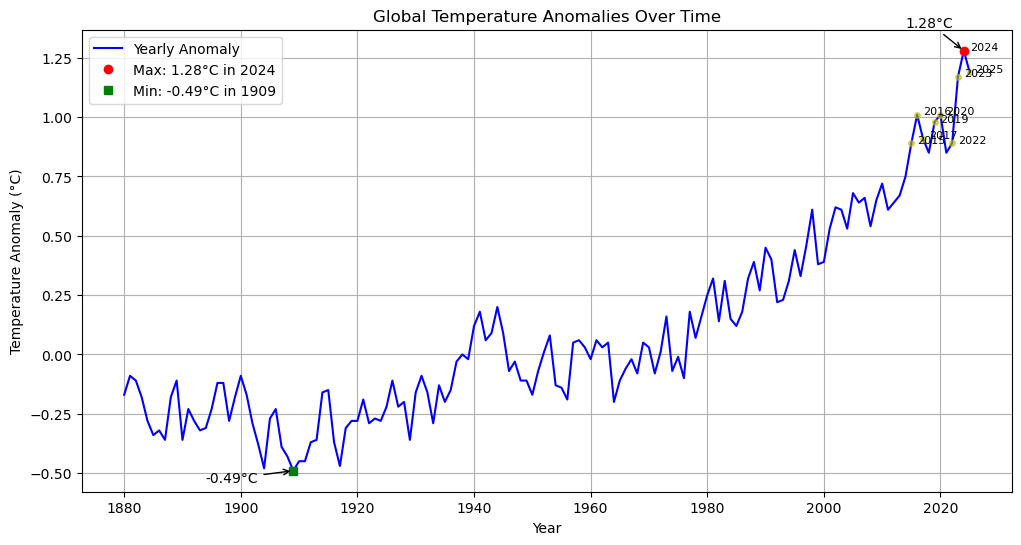

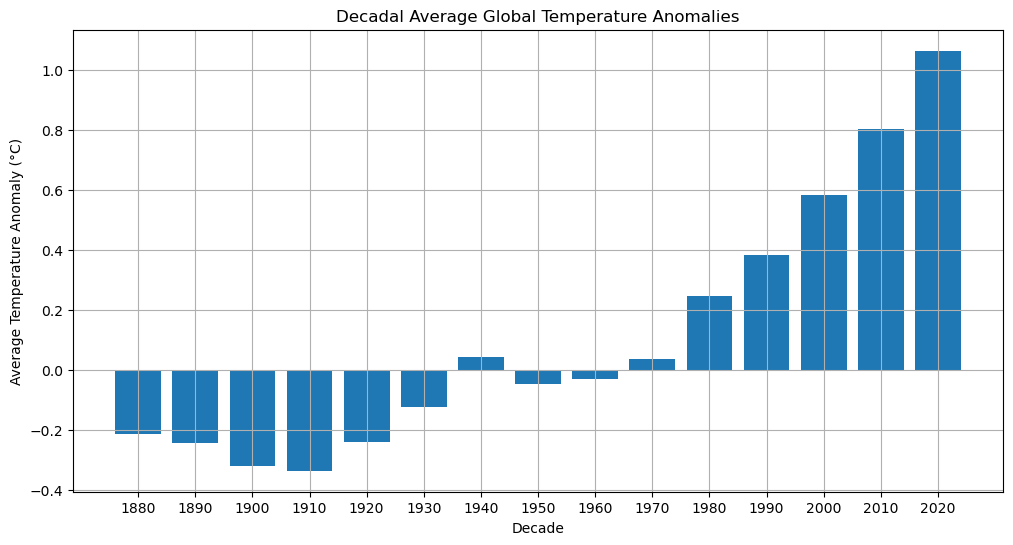

In [5]:
import csv
import logging
import math
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='temperature_analysis.log',
    filemode='a'
)

def load_temperature_csv(filename):
    """Load NASA GISTEMP CSV into a list of dictionaries."""

    total_rows = 0              #Counts number of rows imported
    missing_year = 0            #Counts number of mussing years
    missing_anomaly = 0         #Counts number of missing data values
    
    data = []  # We'll store each row as a dictionary
    
    try:
        with open(filename, 'r') as file:
            next(file)     #Skips first row in csv file, which contains a header, not column names
            reader = csv.DictReader(file)
            
            for row in reader:  # Process each row one by one
                total_rows += 1  #Adds 1 to the count of number of rows
                
                # Step 1: Convert Year to integer safely
                try:
                    row['Year'] = int(row['Year'])
                except ValueError:
                    row['Year'] = None  # If invalid, mark as None
                    missing_year += 1   #Adds 1 to missing year count
                    
                # Step 2: Convert J-D (yearly anomaly) to float safely
                try:
                    row['J-D'] = float(row['J-D'])
                except ValueError:
                    row['J-D'] = None     # If invalid, mark as None
                    missing_anomaly += 1  #Adds 1 to missing anomaly count
                    
                # Step 3: Append the processed row to the data list
                data.append(row)
    
    except FileNotFoundError:      #Logs an error if file can't be opened
        logging.error(f"File {filename} not found")
        return []
    
    if not data:                   #Logs an error if dataset is empty
        logging.warning(f"No valid data found in {filename}")

    logging.info(f"Total rows loaded: {total_rows}")             #Logs number of rows
    logging.info(f"Missing Year values: {missing_year}")         #Logs number of missing years
    logging.info(f"Missing anomaly values: {missing_anomaly}")   #Logs number of missing anomalies
    
    return data     #Stores the loaded and converted data as 'data'

def extract_years_and_anomalies(dataset):
    """Extract aligned lists of years and anomaly values."""

    years = []       #Two lists to hold values that are also 
    anomalies = []   #x-axis and y-axis values in the plots

    for record in dataset:
        year = record['Year']
        value = record['J-D']

        if year is not None and value is not None:
            years.append(year)
            anomalies.append(value)

    return years, anomalies

def compute_average(values):
    """Calculates the average temperature anomaly."""
    total = 0
    count = 0

    for value in values:
        if value is not None:
            total += value
            count += 1

    if count == 0:
        return None

    average = total / count
    return average

def find_max_anomaly(dataset):
    """Calculates the maxiumum temperature anomaly."""
    if len(dataset) == 0:     #If the list is empty retrun None
        return None

    max_record = None

    for record in dataset:
        value = record['J-D']

        #If value is None(record in dataset is corrupt or missing) skip this record
        if value is None:
            continue

        if max_record is None or value > max_record['J-D']:
            max_record = record

    return max_record    

def find_min_anomaly(dataset):
    """Calculates the minimum temperature anomaly."""
    if len(dataset) == 0:     #If the list is empty retrun None
        return None

    min_record = None

    for record in dataset:
        value = record['J-D']

        #If value is None(record in dataset is corrupt or missing) skip this record
        if value is None:
            continue

        if min_record is None or value < min_record['J-D']:
            min_record = record

    return min_record

def compute_std(values):
    """Compute sample standard deviation."""
    
    clean_values = []
    
    for value in values:
        if value is not None:
            clean_values.append(value)

    n = len(clean_values)
    if n < 2:
        logging.warning(f"Not enough valid data to compute standard deviation.")
        return None
    mean = sum(clean_values) / n
    variance = sum((x - mean) ** 2 for x in clean_values) / (n - 1)  # sample SD

    return math.sqrt(variance)

def detect_anomalies(dataset):
    """Return records with statistically extreme temperature anomalies."""
    
    temp_anomalies = []

    for record in dataset:
        if record['J-D'] is not None:
            temp_anomalies.append(record['J-D'])     #Appends value (J-D) only to the list

    mean = compute_average(temp_anomalies)
    std = compute_std(temp_anomalies)

    if mean is None or std is None:
        logging.warning("Cannot compute anomalies due to insufficient data.")
        return []

    extreme_records = []     #Creates a list for all anomalies that have a very high standard deviation from baseline

    for record in dataset:
        value = record['J-D']

        if value is None:
            continue

        if abs(value - mean) > 2 * std:    #abs = absolute value from zero, so will be 8 if (value-mean) = 8 or -8
            extreme_records.append(record)    #Appends whole record to the list so that the year is also extractable.

    logging.info(f"Detected {len(extreme_records)} extreme years")   #Logs number of extreme anomaly years

    return extreme_records

def compute_decadal_averages(dataset):
    """Compute average anomaly per decade."""
    
    decade_data = {}

    for record in dataset:
        year = record['Year']
        value = record['J-D']

        if year is None or value is None:
            continue

        decade = (year // 10) * 10  # e.g. 1998 → 1990   # // means divide by 10 and rounds to an integer (not a decimal)

        if decade not in decade_data:    #If the decade isn’t in the dictionary, create a list.
            decade_data[decade] = []     #If it is there, append the value to the relevant decade list (eg 2020s)

        decade_data[decade].append(value)

    # Now compute averages
    decade_averages = {}

    for decade in decade_data:
        values = decade_data[decade]       #Gives a list of all valid J-D anomaly values for that decade [0.65, 0.72, 0.8..]
        decade_averages[decade] = compute_average(values)     #Calculates the average value for the values in the deacde list

    logging.info(f"Computed decadal averages for {len(decade_averages)} decades")
    logging.info("Decadal averages computed and prepared for plotting")
    
    return decade_averages

def plot_temperature_trend(years, anomalies, max_record, min_record, extreme_records):
    """Plots time_series of global temp anomalies using Matplotlib"""
    """ with highlighted max and min points"""

    #Create temporary variables for max and min values and years (for readability)
    max_year = max_record['Year']
    max_value = max_record['J-D']
    
    min_year = min_record['Year']
    min_value = min_record['J-D']

    #Create the plot, using Matplotlib
    plt.figure(figsize=(12,6))    #Controls size of plot window, if not included there is a default size

    #Line plot of anomalies
    plt.plot(years, anomalies, label='Yearly Anomaly', color='blue')   #Line label in legend, color = line colour

    # Plot extreme anomaly points  (before max and min, or they will cover max)
    for record in extreme_records:
        plt.plot(record['Year'], record['J-D'], 'yo', alpha=0.6, markersize=4)  # yellow circle, transparent, small size

    for record in extreme_records:
        plt.annotate(f"{record['Year']}",
                     xy=(record['Year'], record['J-D']),
                     xytext=(record['Year'] + 1, record['J-D']),
                     fontsize=8)
    
    #Max anomaly plot
    plt.plot(max_year, max_value, 'ro', label=f'Max: {max_value}°C in {max_year}') #Adds marker at max value 'ro' = red circle

    plt.annotate(f'{max_value}°C', xy=(max_year, max_value),        #Adds a pont for the max anomaly value
             xytext=(max_year-10, max_value+0.1),                   #Determines where the spot's label will appear
             arrowprops=dict(facecolor='black', arrowstyle='->'))   #Deterimes colour and style of arrow

    # Min anomaly point
    plt.plot(min_year, min_value, 'gs', label=f'Min: {min_value}°C in {min_year}')   #Adds marker at min value 'gs' = green square
    plt.annotate(f'{min_value}°C',
                 xy=(min_year, min_value),
                 xytext=(min_year-15, min_value-0.05),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))

   

    #Labels, legeng, grid
    plt.xlabel("Year")                                  #x-axis label
    plt.ylabel("Temperature Anomaly (°C)")              #y-axis label
    plt.title("Global Temperature Anomalies Over Time") #Graph title
    plt.grid(True)                                      #Shows gridlines
    plt.legend()                                        #Shows legend
    plt.savefig("temperature_trend.png")                #Saves the graph
    plt.show()                                          #Display the plot

def plot_decadal_averages(decades, averages):
    """Plot decadal average anomalies as a bar chart."""
    
    plt.figure(figsize=(12,6))

    plt.bar(decades, averages, width=8)   #Plot bar chart, decades=x-axis, averages=y-axis, 8 wide
    plt.xticks(decades)                   #Centres labels under the bars
    
    plt.xlabel("Decade")
    plt.ylabel("Average Temperature Anomaly (°C)")
    plt.title("Decadal Average Global Temperature Anomalies")

    plt.grid(True)

    plt.show()

# =========================
# CONTROL SECTION
# =========================

# Load data
temperature_data = load_temperature_csv("temperature_anomalies.csv")

# Extract time series
years, anomalies = extract_years_and_anomalies(temperature_data)

# Compute stats
avg = compute_average(anomalies)
std_dev = compute_std(anomalies)

# Logging
logging.info(f"Average anomaly: {compute_average(anomalies):.3f}")
logging.info(f"Standard deviation: {std_dev:.3f}")

# Detect extremes
extreme_records = detect_anomalies(temperature_data)

# Find max/min
max_record = find_max_anomaly(temperature_data)
min_record = find_min_anomaly(temperature_data)

# NEW: Decadal analysis
decade_averages = compute_decadal_averages(temperature_data)
decades = sorted(decade_averages.keys())   #Gives alll the keys in the dictionary (in this case the decade names) sorted 1990, 2000, 2010..

avg_values = []     #Converts the dictionary to an ordered list
for d in decades:   #'d' being each decade
    value = decade_averages[d]   #Get the average J-D value for that decade
    avg_values.append(value)     #Add it to the avg_values list

# Plotting
plot_temperature_trend(years, anomalies, max_record, min_record, extreme_records)
plot_decadal_averages(decades, avg_values)

   

In [2]:
print(f"Loaded {len(temperature_data)} records")
print(temperature_data[:5])  # Show first 5 rows to check

Loaded 147 records
[{'Year': 1880, 'Jan': '-0.19', 'Feb': '-0.25', 'Mar': '-0.09', 'Apr': '-0.16', 'May': '-0.1', 'Jun': '-0.21', 'Jul': '-0.18', 'Aug': '-0.1', 'Sep': '-0.14', 'Oct': '-0.23', 'Nov': '-0.22', 'Dec': '-0.19', 'J-D': -0.17, 'D-N': '***', 'DJF': '***', 'MAM': '-0.12', 'JJA': '-0.17', 'SON': '-0.2'}, {'Year': 1881, 'Jan': '-0.2', 'Feb': '-0.15', 'Mar': '0.02', 'Apr': '0.04', 'May': '0.07', 'Jun': '-0.19', 'Jul': '0.01', 'Aug': '-0.04', 'Sep': '-0.15', 'Oct': '-0.21', 'Nov': '-0.18', 'Dec': '-0.07', 'J-D': -0.09, 'D-N': '-0.1', 'DJF': '-0.18', 'MAM': '0.04', 'JJA': '-0.07', 'SON': '-0.18'}, {'Year': 1882, 'Jan': '0.16', 'Feb': '0.14', 'Mar': '0.04', 'Apr': '-0.16', 'May': '-0.14', 'Jun': '-0.23', 'Jul': '-0.16', 'Aug': '-0.08', 'Sep': '-0.15', 'Oct': '-0.23', 'Nov': '-0.17', 'Dec': '-0.36', 'J-D': -0.11, 'D-N': '-0.09', 'DJF': '0.08', 'MAM': '-0.09', 'JJA': '-0.16', 'SON': '-0.18'}, {'Year': 1883, 'Jan': '-0.29', 'Feb': '-0.36', 'Mar': '-0.12', 'Apr': '-0.18', 'May': '-0.18

In [10]:
print(len(anomalies))
print(anomalies[:10])

146
[-0.17, -0.09, -0.11, -0.18, -0.28, -0.34, -0.32, -0.36, -0.18, -0.11]


In [11]:
avg = compute_average(anomalies)
print("Average anomaly:", avg)

Average anomaly: 0.08041095890410968


In [12]:
max_record = find_max_anomaly(temperature_data)
print(max_record)
print("Highest anomaly year:", max_record['Year'])
print("Anomaly value:", max_record['J-D'])

{'Year': 2024, 'Jan': '1.25', 'Feb': '1.43', 'Mar': '1.39', 'Apr': '1.31', 'May': '1.16', 'Jun': '1.24', 'Jul': '1.2', 'Aug': '1.3', 'Sep': '1.23', 'Oct': '1.34', 'Nov': '1.29', 'Dec': '1.26', 'J-D': 1.28, 'D-N': '1.29', 'DJF': '1.34', 'MAM': '1.29', 'JJA': '1.25', 'SON': '1.29'}
Highest anomaly year: 2024
Anomaly value: 1.28


In [13]:
min_record = find_min_anomaly(temperature_data)

print("Lowest anomaly year:", min_record['Year'])
print("Anomaly value:", min_record['J-D'])

Lowest anomaly year: 1909
Anomaly value: -0.49


In [14]:
std_dev = compute_std(anomalies)
print(f"Standard Deviation: {std_dev:.3f}")

Standard Deviation: 0.401
